<a href="https://colab.research.google.com/github/heyitsmialee/PRAGma/blob/main/pragma_260501.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. 양산 DES 속도 예측 모델

In [3]:
!pip install optuna

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from lightgbm import LGBMRegressor # Only LGBMRegressor is needed now
from sklearn.metrics import r2_score # Only r2_score is needed for evaluation
import joblib
import json
import shap
import matplotlib.pyplot as plt
import os
import seaborn as sns
import lightgbm as lgb

def load_and_preprocess_data(csv_path='./Train_0319.csv'):
    raw_df = pd.read_csv(csv_path, encoding='cp949')

    df = raw_df[[
        'DRY FILM 정보', '선폭 OFFSET', '양산DES 속도',
        '거래처', '제품군', '공법구분', 'LAYER', '도금구분', '노광 설비정보',
        'DES 설비정보', '정면 설비정보', 'Cu 표면두께 Max_Val', 'Cu 표면두께 AVG_VAL',
        'Cu 표면두께 Min_Val', 'Cu 표면두께 Std_Val', 'Cu 표면두께 Median_Val',
        '재작업사유', '분석치_Etch factor', '분석치_Etching(염화동) - Cu',
        '분석치_Etching(염화동) - HCl', '분석치_Etching(염화동) - 비중',
        '분석치_Etching(염화동) - 온도', '분석치_Etching-첨가제(HB-120EF)',
        '분석치_Etching량', '분석치_Soft Etch - Cu', '분석치_Soft Etch - H2SO4',
        '분석치_Soft Etch - SPS', '분석치_박리액 - 농도', '분석치_수세수 - pH',
        '분석치_현상액 - pH', '분석치_현상액 - 농도'
    ]].copy()

    new_cols = [
        'df_type', 'width_offset', 'mass_des_speed',
        'customer', 'product_family', 'process_type', 'layer_count',
        'plating_type', 'expo_eq_id', 'des_eq_id', 'brush_eq_id', 'cu_thick_max',
        'cu_thick_avg', 'cu_thick_min', 'cu_thick_std', 'cu_thick_median',
        'rework_history', 'etch_factor', 'meas_etch_cu', 'meas_etch_hcl',
        'meas_etch_sg', 'meas_etch_temp', 'meas_etch_additive', 'meas_etch_amount',
        'meas_softetch_cu', 'meas_softetch_h2so4', 'meas_softetch_sps',
        'meas_strip_conc', 'meas_rinse_ph', 'meas_dev_ph', 'meas_dev_conc'
    ]
    df.columns = new_cols

    # 1. 범주형 변수 중 일부는 남기고 불필요한 것 제거
    drop_cols = [
        'df_type', 'customer', 'product_family', 'process_type',
        'layer_count', 'plating_type', 'width_offset'
    ]
    df = df.drop(columns=drop_cols)

    # 타겟 변수 분리
    y = df['mass_des_speed']
    # mass_des_speed를 소수점 둘째자리까지 반올림
    y = y.round(2)
    x = df.drop(columns=['mass_des_speed'])

    # 범주형 / 수치형 피처 분리
    categorical_features = ['rework_history', 'expo_eq_id', 'des_eq_id', 'brush_eq_id']
    numeric_features = [col for col in x.columns if col not in categorical_features]

    # 결측치 처리
    x[numeric_features] = x[numeric_features].fillna(x[numeric_features].median())
    for cat_col in categorical_features:
        x[cat_col] = x[cat_col].fillna('Unknown').astype(str)

    # 3. Train_Val / Test 분리
    # y_train_val 변수명 중복 및 잘못된 할당 수정
    x_temp, x_test_set, y_temp, y_test_set = train_test_split(x, y, test_size=0.2, random_state=42)
    x_train_set, x_val_set, y_train_set, y_val_set = train_test_split(x_temp, y_temp, test_size=0.25, random_state=42)

    # 4. 전처리 파이프라인
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ])

    x_train_transformed = preprocessor.fit_transform(x_train_set)
    x_val_transformed = preprocessor.transform(x_val_set)
    x_test_transformed = preprocessor.transform(x_test_set)

    cat_encoder = preprocessor.named_transformers_['cat']
    encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_features)
    final_columns = numeric_features + list(encoded_cat_cols)

    df_train_set = pd.DataFrame(x_train_transformed, columns=final_columns, index=x_train_set.index)
    df_train_set['mass_des_speed'] = y_train_set # y_train_set으로 올바르게 할당

    df_val_set = pd.DataFrame(x_val_transformed, columns=final_columns, index=x_val_set.index)
    df_val_set['mass_des_speed'] = y_val_set

    df_test_set = pd.DataFrame(x_test_transformed, columns=final_columns, index=x_test_set.index)
    df_test_set['mass_des_speed'] = y_test_set

    joblib.dump(preprocessor, 'preprocessor.pkl')

    return df_train_set, df_val_set, df_test_set


# 기존 select_best_regressor, tune_regressor_hyperparameters, tune_and_train_regressor 함수는 사용자의 요청에 따라 제거됩니다.

def train_and_evaluate(df_train_eval, df_val_eval, df_test_eval):
    # 훈련 및 검증 데이터를 결합하여 최종 모델 학습에 사용
    x_train_full = pd.concat([df_train_eval.drop(columns=['mass_des_speed']), df_val_eval.drop(columns=['mass_des_speed'])])
    y_train_full = pd.concat([df_train_eval['mass_des_speed'], df_val_eval['mass_des_speed']])

    x_test_eval = df_test_eval.drop(columns=['mass_des_speed'])
    y_test_eval = df_test_eval['mass_des_speed']

    print("--- LightGBM 모델 고정 파라미터로 학습 시작 ---")
    # 사용자 지정 고정 파라미터
    fixed_params = {'n_estimators': 151, 'learning_rate': 0.13861570640452262, 'max_depth': 13}
    model = LGBMRegressor(**fixed_params, random_state=42, verbose=-1)
    model.fit(x_train_full, y_train_full)
    name = "LightGBM" # 모델 이름 고정

    print("\n=== 데이터셋별 양산 DES 속도 회귀 성능 ===")
    pred = model.predict(x_test_eval)
    # 예측값 소수점 둘째자리까지 반올림
    pred = np.round(pred, 2)
    sim_r2 = r2_score(y_test_eval, pred)
    print(f"[Test Set] R2 Score: {sim_r2:.4f}")

    joblib.dump(model, f'best_{name}_mass_speed_regressor.pkl')

    with open('feature_columns_regressor.json', 'w', encoding='utf-8') as f:
        json.dump(x_train_full.columns.tolist(), f, ensure_ascii=False, indent=4)

    # SHAP 분석을 위해 전체 훈련 데이터 반환
    return model, name, x_train_full, x_test_eval, y_test_eval


def generate_shap_analysis(model, x_train_shap, x_test_shap, y_test_shap):
    print("\n--- [4] SHAP 분석 시작 ---")

    # 이제 LightGBM만 사용하므로 isinstance 체크를 간소화
    if isinstance(model, LGBMRegressor):
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(x_test_shap)
        expected_value = explainer.expected_value
    else:
        # 비트리 모델 폴백 (이 경우 항상 LGBM일 것이므로 실행되지 않음)
        x_train_summary = shap.kmeans(x_train_shap, 100)
        explainer = shap.KernelExplainer(model.predict, x_train_summary)
        shap_values = explainer.shap_values(x_test_shap)
        expected_value = explainer.expected_value

    if isinstance(expected_value, (list, np.ndarray)):
        expected_value = expected_value[0]

    # 1. SHAP 플롯 이미지 저장
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, x_test_shap, plot_type="bar", show=False)
    plt.tight_layout()
    plt.savefig("shap_summary_bar.png")
    plt.close()

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, x_test_shap, show=False)
    plt.tight_layout()
    plt.savefig("shap_summary_dot.png")
    plt.close()

    print("SHAP 플롯 이미지 저장 완료 (shap_summary_bar.png, shap_summary_dot.png)")

    # 2. RAG용 마크다운 문서 생성
    generate_rag_text(shap_values, x_test_shap, expected_value, y_test_shap)


def generate_rag_text(shap_values, x_test_rag, expected_value, y_test_rag):
    print("\n--- [5] RAG용 SHAP 분석 마크다운 생성 ---")

    vals = np.abs(shap_values).mean(0)
    feature_names = x_test_rag.columns
    fi_df = pd.DataFrame(list(zip(feature_names, vals)), columns=['feature', 'importance'])
    fi_df.sort_values(by=['importance'], ascending=False, inplace=True)

    # 마크다운 텍스트 구성 시작
    md_content = "# SHAP(SHapley Additive exPlanations) 분석 기반 모델 해석 리포트\n\n"
    md_content += "> 본 리포트는 RAG(Retrieval-Augmented Generation) 시스템이 사용자의 질문에 답할 때 모델의 예측 근거를 제공하기 위해 생성되었습니다.\n\n"

    md_content += "## 1. 글로벌 피처 중요도 (Global Feature Importance)\n"
    md_content += "전체 테스트 데이터를 기준으로, 모델이 **양산 DES 속도**를 예측할 때 가장 크게 의존하는 상위 10개 피처(변수)입니다. 중요도 수치가 높을수록 모델 예측에 미치는 영향력이 큽니다.\n\n"

    md_content += "| 순위 | 변수명 | 평균 SHAP 중요도 (Absolute) |\n"
    md_content += "|---|---|---|\n"
    for i, row in enumerate(fi_df.head(10).itertuples(), 1):
         md_content += f"| {i} | `{row.feature}` | {row.importance:.4f} |\n"
    md_content += "\n"

    md_content += "## 2. 주요 변수별 영향 방향성 (Feature Impact Direction)\n"
    md_content += "상위 5개 주요 변수가 양산 DES 속도의 **증가** 또는 **감소**에 어떻게 기여하는지 분석한 결과입니다.\n\n"

    for feature in fi_df['feature'].head(5):
        feature_idx = list(x_test_rag.columns).index(feature)
        f_shap = shap_values[:, feature_idx]
        f_val = x_test_rag[feature].values

        # 피처 값과 SHAP 값의 상관관계 계산 (Nan 제외)
        mask = ~np.isnan(f_val) & ~np.isnan(f_shap)
        if np.sum(mask) > 1: # 데이터가 충분할 때
            corr = np.corrcoef(f_val[mask], f_shap[mask])[0, 1]
        else:
            corr = 0

        md_content += f"### 변수: `{feature}`\n"
        if corr > 0.3:
             md_content += f"- **경향성**: 양의 상관관계 (이 변수 값이 커질수록 예측 속도를 **높이는** 경향이 있습니다.)\n"
        elif corr < -0.3:
             md_content += f"- **경향성**: 음의 상관관계 (이 변수 값이 커질수록 예측 속도를 **낮추는** 경향이 있습니다.)\n"
        else:
             md_content += f"- **경향성**: 비선형적 또는 특정 구간에서 영향을 미칩니다 (값의 크기만으로 단순 증가/감소를 정의하기 어렵습니다.)\n"
        md_content += "- **설명**: SHAP 플롯(`shap_summary_dot.png`)을 참고하면 이 변수의 세부적인 데이터 분포와 예측치 변동 폭을 확인할 수 있습니다.\n\n"


    md_content += "## 3. 특정 샘플(Local) 예측 해석 예시\n"
    md_content += "모델이 개별 데이터(테스트 셋의 첫 번째 행)를 예측할 때, 어떤 변수들이 어떻게 더하고 빼져서 최종 결과가 나왔는지 보여주는 예시입니다.\n\n"

    md_content += f"- **모델의 평균 기대 예측값(Base Value)**: `{expected_value:.4f}`\n"
    md_content += f"- **실제 타겟(양산 DES 속도) 값**: `{y_test_rag.iloc[0]:.4f}`\n\n"

    # 첫 번째 샘플 분석
    sample_shap = shap_values[0]
    sample_vals = x_test_rag.iloc[0]

    sample_df = pd.DataFrame({
        'Feature': x_test_rag.columns,
        'Feature Value': sample_vals,
        'SHAP Value': sample_shap
    })
    # 영향력이 큰(절대값이 큰) 순서대로 정렬
    sample_df['abs_shap'] = sample_df['SHAP Value'].abs()
    sample_df = sample_df.sort_values(by='abs_shap', ascending=False).head(7)

    prediction = expected_value + np.sum(sample_shap)

    md_content += "| 변수명 | 현재 데이터의 피처 값 | 예측치 변동량 (SHAP) | 변동 방향 |\n"
    md_content += "|---|---|---|---|\n"
    for _, row in sample_df.iterrows():
        direction = "🟢 증가 (Speed Up)" if row['SHAP Value'] > 0 else "🔴 감소 (Speed Down)"
        md_content += f"| `{row['Feature']}` | {row['Feature Value']:.4f} | {row['SHAP Value']:.4f} | {direction} |\n"

    md_content += f"\n- 위와 같이 각 변수들의 기여도(SHAP Value)를 모두 평균 기대 예측값에 합산하면 **최종 예측값 `{prediction:.4f}`** 이(가) 도출됩니다.\n"

    # 마크다운 파일 저장
    md_file_path = "shap_analysis_for_rag.md"
    with open(md_file_path, "w", encoding="utf-8") as f:
        f.write(md_content)

    print(f"RAG용 SHAP 분석 마크다운 저장 완료 ({md_file_path})\n")


if __name__ == "__main__":
    csv_file_path = './Train_0319.csv'

    if not os.path.exists(csv_file_path):
        print(f"\n[에러] '{csv_file_path}' 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
    else:
        print("--- [1] 데이터 로드 및 전처리 시작 ---")
        train_df, val_df, test_df = load_and_preprocess_data(csv_path=csv_file_path)

        print("\n--- [2] 회귀 모델 학습 시작 ---") # 메시지 변경
        # 이제 train_and_evaluate 함수가 고정된 LightGBM 학습을 처리합니다.
        final_model_obj, final_model_name, x_train_final, x_test_final, y_test_final = train_and_evaluate(train_df, val_df, test_df)

        print("\n--- [3] 파이프라인 모델 학습 완료 ---")

        # SHAP 분석 실행
        generate_shap_analysis(final_model_obj, x_train_final, x_test_final, y_test_final)

        print("\n모든 작업이 성공적으로 완료되었습니다. 생성된 마크다운 파일을 RAG 시스템에 로드하여 활용하세요.")

--- [1] 데이터 로드 및 전처리 시작 ---

--- [2] 회귀 모델 학습 시작 ---
--- LightGBM 모델 고정 파라미터로 학습 시작 ---

=== 데이터셋별 양산 DES 속도 회귀 성능 ===
[Test Set] R2 Score: 0.9333

--- [3] 파이프라인 모델 학습 완료 ---

--- [4] SHAP 분석 시작 ---
SHAP 플롯 이미지 저장 완료 (shap_summary_bar.png, shap_summary_dot.png)

--- [5] RAG용 SHAP 분석 마크다운 생성 ---
RAG용 SHAP 분석 마크다운 저장 완료 (shap_analysis_for_rag.md)


모든 작업이 성공적으로 완료되었습니다. 생성된 마크다운 파일을 RAG 시스템에 로드하여 활용하세요.


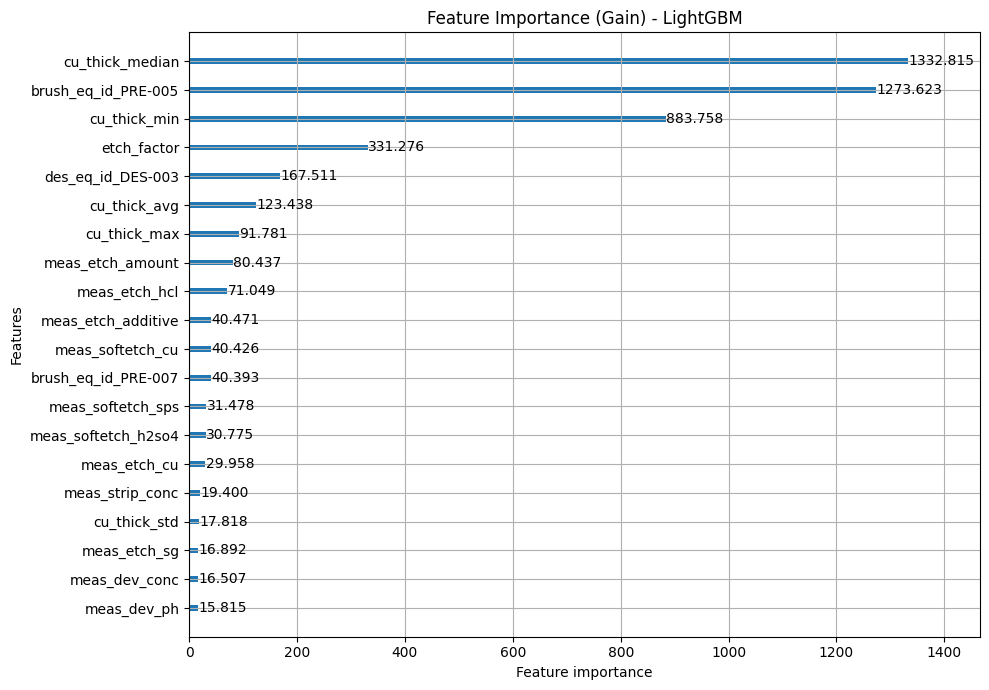

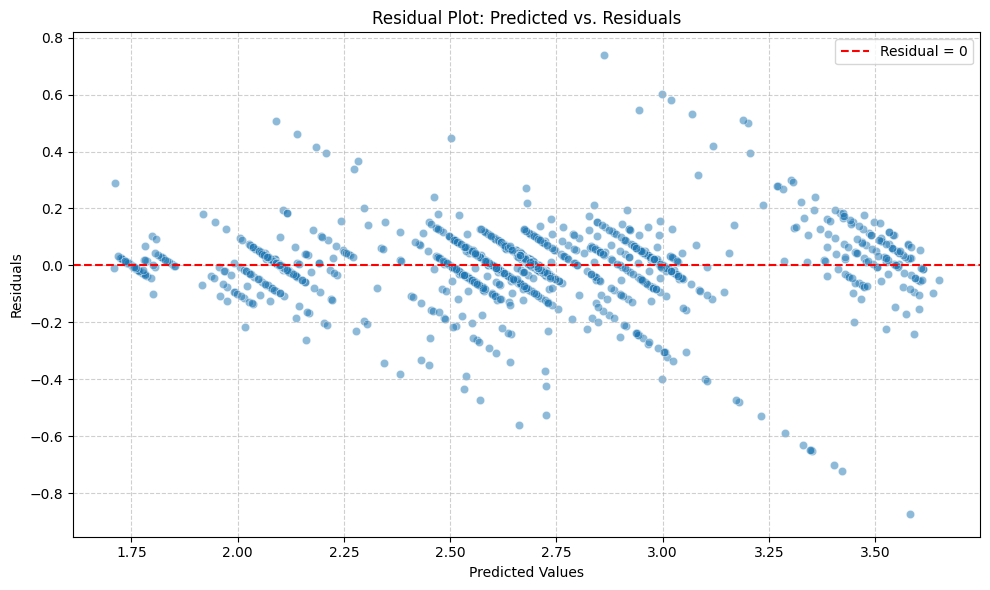

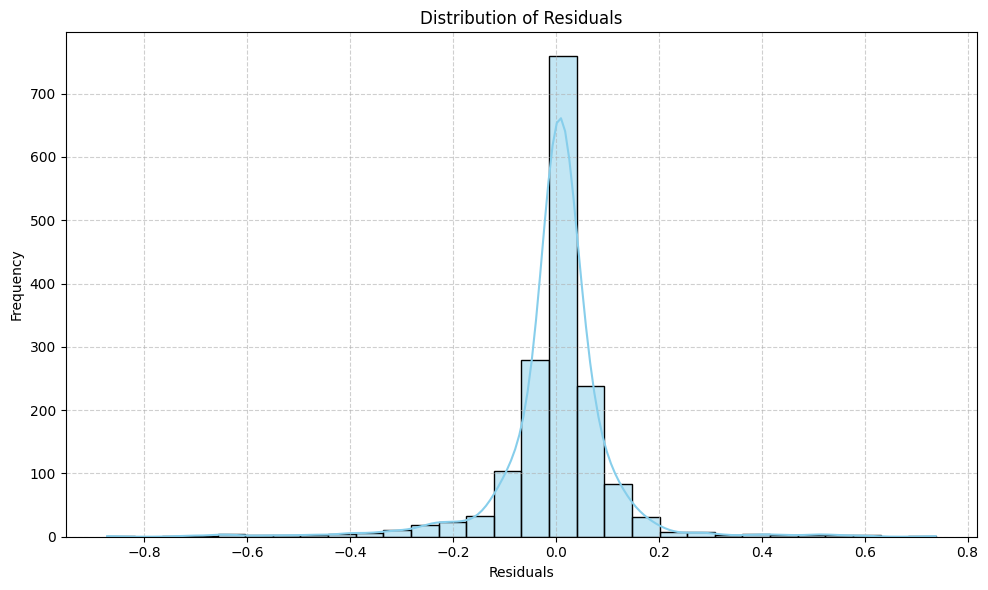

모델 성능 시각화가 완료되었습니다.


In [25]:
# 예측값 계산
y_pred = final_model_obj.predict(x_test_final)

# 1. 변수 중요도 (Feature Importance) 확인
plt.figure(figsize=(10, 7))

# 모델 타입에 따라 Feature Importance 시각화 방법 변경
if final_model_name == "LightGBM":
    lgb.plot_importance(final_model_obj, importance_type='gain', max_num_features=20, ax=plt.gca())
    plt.title("Feature Importance (Gain) - LightGBM")
elif hasattr(final_model_obj, 'feature_importances_'):
    # 트리 기반 모델 (RandomForest, GradientBoosting, XGBoost)의 경우
    feature_importances = pd.Series(final_model_obj.feature_importances_, index=x_test_final.columns)
    feature_importances.nlargest(20).plot(kind='barh', ax=plt.gca())
    plt.title(f"Feature Importance ({final_model_name})")
    plt.xlabel("Importance")
    plt.ylabel("Features")
else:
    print("현재 모델은 Feature Importance를 직접 제공하지 않거나, 지원되지 않는 유형입니다.")

plt.tight_layout()
plt.show()

# 2. 잔차 분석 (Residual Analysis) 시각화
# 예측값과 실제값의 차이인 잔차를 계산합니다.
residuals = y_test_final - y_pred

# 잔차 산점도 그리기: 예측값 vs 잔차
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', label='Residual = 0') # 오차가 0인 기준선
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot: Predicted vs. Residuals")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 잔차 분포 히스토그램: 잔차가 정규 분포를 따르는지 확인
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30, color='skyblue')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("모델 성능 시각화가 완료되었습니다.")